In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 35 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (10.3 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 121749 files and direc

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import matplotlib

# 맑은 고딕 적용
matplotlib.rc("font", family = "AppleGothic")
# 음수 표시
matplotlib.rc('axes', unicode_minus=False)
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
# matplotlib의 폰트를 설정합니다.
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호가 깨지는 문제를 방지


In [ ]:
# 실행결과 경고메시지 출력 제외
import warnings

warnings.filterwarnings('ignore')

In [ ]:
import pandas as pd
import numpy as np

# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib

import seaborn as sns

In [ ]:
import statsmodels.api as sm
from scipy.stats import shapiro
from scipy.stats import f_oneway


In [ ]:
plt.rc('font', family='NanumBarunGothic')

## 데이터 설명   

목표변수
- Price 중고차 가격 (단위 : 1,000원)  

설명변수

- Name : 자동차 브랜드와 모델의 이름
- Location : 자동차를 팔거나 구매할 수 있는 위치
- Year : 모델의 년도 혹은 버전
- Kilometers_Driven : 이전 소유주의 차량 주행거리(Km)
- Fuel_Type : 자동차의 사용연료의 종류
- Transmission : 자동차의 사용 변속기 종류(Manual/Automatic)
- Owner_Type : 소유권이 직접 소유인지, 중고 소유인지 여부
- Mileage : 자동차 회사가 제공하는 표준주행거리(kmpl)
- Engine : 엔진의 배기량(cc)
- Power : 엔진의 최대 출력(bhp)
- Seats : 차의 좌석 수
- New_Price : 뉴 모델의 가격

## 데이터 전처리

In [ ]:
df_raw = pd.read_csv('/content/drive/MyDrive/PoBigA/종합실습1/real_final.csv')
df_raw.head()

,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Seats,Brand,Vehicle_Age,city_location,engine_group,log_price,Power_log
0,72000,2,1,1,26.60,998.0,5.0,18,14,2,0,7.894944,4.063198
1,41000,0,1,1,19.67,1582.0,5.0,11,9,2,1,9.860737,4.837868
2,46000,1,1,1,18.20,1199.0,5.0,10,13,3,1,8.839178,4.485260
3,87000,0,1,1,20.77,1248.0,7.0,18,12,3,1,9.126824,4.485936
4,40670,0,2,2,15.20,1968.0,5.0,1,11,3,2,10.210815,4.947340


<Power 문제>

In [ ]:
df_raw.shape

(5975, 13)

In [ ]:
df_raw.info() #데이터 열 정보 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5975 entries, 0 to 5974
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Kilometers_Driven  5975 non-null   int64  
 1   Fuel_Type          5975 non-null   int64  
 2   Transmission       5975 non-null   int64  
 3   Owner_Type         5975 non-null   int64  
 4   Mileage            5975 non-null   float64
 5   Engine             5975 non-null   float64
 6   Seats              5975 non-null   float64
 7   Brand              5975 non-null   int64  
 8   Vehicle_Age        5975 non-null   int64  
 9   city_location      5975 non-null   int64  
 10  engine_group       5975 non-null   int64  
 11  log_price          5975 non-null   float64
 12  Power_log          5975 non-null   float64
dtypes: float64(5), int64(8)
memory usage: 607.0 KB


In [ ]:
df_raw.isnull().sum() #데이터 결측값 확인

Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               0
Seats                0
Brand                0
Vehicle_Age          0
city_location        0
engine_group         0
log_price            0
Power_log            0
dtype: int64

In [ ]:
df_raw['log_price'].describe() #목표변수 기술통계량 확인

count    5975.000000
mean        9.200450
std         0.870272
min         6.979210
25%         8.602087
50%         9.084269
75%         9.686393
max        12.410134
Name: log_price, dtype: float64

평균(mean)과 최솟값(min)/ 평균과 최댓값의 차이가 많이 난다.   
-> 편차가 많음  
-> 이상치 및 결측치 파악 필요

In [ ]:
df_raw.describe() #수치형 변수 요약 통계

,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Seats,Brand,Vehicle_Age,city_location,engine_group,log_price,Power_log
count,5975.000000,5975.000000,5975.000000,5975.000000,5975.000000,5975.000000,5975.000000,5975.000000,5975.000000,5975.000000,5975.000000,5975.000000,5975.000000
mean,52966.711632,0.488033,1.294393,1.188285,18.459632,1611.058107,5.255900,15.703431,10.424770,2.707782,1.413556,9.200450,4.641618
std,27075.637684,0.528228,0.455808,0.436680,4.141416,595.002692,0.773443,8.099404,3.157455,0.842043,0.907609,0.870272,0.412802
min,171.000000,0.000000,1.000000,1.000000,6.400000,624.000000,2.000000,0.000000,5.000000,1.000000,0.000000,6.979210,3.532226
25%,32442.000000,0.000000,1.000000,1.000000,15.600000,1197.000000,5.000000,10.000000,8.000000,2.000000,1.000000,8.602087,4.356709
50%,51500.000000,0.000000,1.000000,1.000000,18.440000,1493.000000,5.000000,17.000000,10.000000,3.000000,1.000000,9.084269,4.591071
75%,70000.000000,1.000000,2.000000,1.000000,21.110000,1968.000000,5.000000,19.000000,12.000000,3.000000,2.000000,9.686393,4.927978
max,131000.000000,3.000000,2.000000,4.000000,33.540000,5998.000000,10.000000,31.000000,26.000000,4.000000,3.000000,12.410134,6.423247


seats 변수의 최솟값이 0 인걸 봐서 이상치 감지 (좌석수가 없는 차는 없다)

다들 이거 보고나면 power 확인하는 부분은 지울게영   
아님 이것두 보고서 추가해도됩니다
처음 짠 코드대로 전기수 코드 참고해서 단위 분리후 power 결측치는 평균치 대체할게요

In [ ]:
df_raw['Power_log'].describe()

count    5975.000000
mean        4.641618
std         0.412802
min         3.532226
25%         4.356709
50%         4.591071
75%         4.927978
max         6.423247
Name: Power_log, dtype: float64

df_raw['Power'] 단위분리하면 결측치 늘어나는 이유 찾았어용 !!  
Power 열에 'null bhp'가 129개나 있는거 밑에 보이죵?  
그래서 단위 분리하니까 null값이 결측치로 추가되는거임 ~~

In [ ]:
df_raw['Power_log'].value_counts()

4.304065    227
4.591071    134
4.725358    131
4.941642    119
4.302713    119
           ... 
4.790238      1
5.828946      1
5.424950      1
4.393214      1
4.591375      1
Name: Power_log, Length: 371, dtype: int64

단위가 있는 데이터 type 변환

In [ ]:
df_raw.head(1)

,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Seats,Brand,Vehicle_Age,city_location,engine_group,log_price,Power_log,Brand_Group
0,72000,2,1,1,26.6,998.0,5.0,17,14,2,0,7.894944,4.063198,NaN


In [ ]:
df_raw.isnull().sum()

Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 0
Engine                  0
Seats                   0
Brand                   0
Vehicle_Age             0
city_location           0
engine_group            0
log_price               0
Power_log               0
Brand_Group          5934
dtype: int64

mileage, engine, power 단위 추출

In [ ]:
# df_raw['Mileage'] = df_raw['Mileage'].str.extract(r'(\d+\.?\d*)').astype(float)
# df_raw['Engine'] = df_raw['Engine'].str.extract(r'(\d+\.?\d*)').astype(float)
# df_raw['Power'] = df_raw['Power'].str.extract(r'(\d+\.?\d*)').astype(float)

In [ ]:
df_raw.head() #단위 빼고 실수형으로 전환 확인

,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Seats,Brand,Vehicle_Age,city_location,engine_group,log_price,Power_log,Brand_Group
0,72000,2,1,1,26.60,998.0,5.0,17,14,2,0,7.894944,4.063198,NaN
1,41000,0,1,1,19.67,1582.0,5.0,10,9,2,1,9.860737,4.837868,NaN
2,46000,1,1,1,18.20,1199.0,5.0,9,13,3,1,8.839178,4.485260,NaN
3,87000,0,1,1,20.77,1248.0,7.0,17,12,3,1,9.126824,4.485936,NaN
4,40670,0,2,2,15.20,1968.0,5.0,1,11,3,2,10.210815,4.947340,NaN


Fuel_type의 데이터 값 0~4로 변경

In [ ]:
df_raw['Fuel_Type'].value_counts()

0    3099
1    2768
2      57
3      10
Name: Fuel_Type, dtype: int64

In [ ]:
df_raw['Fuel_Type'] = df_raw['Fuel_Type'].replace('Diesel', 0)
df_raw['Fuel_Type'] = df_raw['Fuel_Type'].replace('Petrol', 1)
df_raw['Fuel_Type'] = df_raw['Fuel_Type'].replace('CNG', 2)
df_raw['Fuel_Type'] = df_raw['Fuel_Type'].replace('LPG', 3)
df_raw['Fuel_Type'] = df_raw['Fuel_Type'].replace('Electric', 4)

Fuel_Type 데이터타입 확인


In [ ]:
df_raw['Fuel_Type'].dtypes

dtype('int64')

In [ ]:
#Tranmission 데이터 값 변경

# Manual -> 1, Automatic -> 2
df_raw['Transmission'] = df_raw['Transmission'].replace('Manual', 1)
df_raw['Transmission'] = df_raw['Transmission'].replace('Automatic', 2)

Transmission 데이터 타입 확인

In [ ]:
df_raw['Transmission'].dtypes

dtype('int64')

In [ ]:
#Owner_type 고유값 확인 및 수치화

df_raw['Owner_Type'].unique()

array([1, 2, 3, 4])

In [ ]:
df_raw['Owner_Type'] = df_raw['Owner_Type'].replace('First', 1)
df_raw['Owner_Type'] = df_raw['Owner_Type'].replace('Second', 2)
df_raw['Owner_Type'] = df_raw['Owner_Type'].replace('Third', 3)
df_raw['Owner_Type'] = df_raw['Owner_Type'].replace('Fourth & Above', 4)

In [ ]:
df_raw.dtypes #범주형변수 수치화 변경 확인

Kilometers_Driven      int64
Fuel_Type              int64
Transmission           int64
Owner_Type             int64
Mileage              float64
Engine               float64
Seats                float64
Brand                  int64
Vehicle_Age            int64
city_location          int64
engine_group           int64
log_price            float64
Power_log            float64
dtype: object

### 결측치 처리

In [ ]:
df_raw.isnull().sum()

Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               0
Seats                0
Brand                0
Vehicle_Age          0
city_location        0
engine_group         0
log_price            0
Power_log            0
dtype: int64

 New_Price의 결측값이 너무 많이 발견되어, New_Price 열을 삭제하기로 결정

In [ ]:
# df_raw.drop(labels = 'New_Price', axis = 1, inplace = True)

In [ ]:
#Toyota Prius 2009-2016 Z4(하이브리드)의 결측치 값을 23.91 kmpl로 변경
df_raw.loc[4446, 'Mileage'] = 23.91

In [ ]:
#Mahindra E Verito D4(전기차)의 결측치 삭제(결측치 1개라 모델에 영향 없을거라 판단)
df_raw = df_raw.dropna(subset=['Mileage'])

In [ ]:
#Engine, Power 결측치는 평균치 대체
df_raw['Engine'].fillna(df_raw['Engine'].mean(), inplace=True)
df_raw['Power_log'].fillna(df_raw['Power_log'].mean(), inplace=True)

Seats 결측치 브랜드별로 모아서 보려고 한 코드. 대부분의 자동차 좌석수는 5개이고 어떤브랜드는 좌석수가 다 결측치인 브랜드도 있어서 좌석수는 최빈값 대체

마루티 브랜드의 데이터들을 모아봄. 이 브랜드의 데이터들은 다 Seats

In [ ]:
#Seats 결측치는 최빈값 대체
mode_seats = df_raw['Seats'].mode()[0] #최빈값 중 첫 번째 값을 가져옴
df_raw['Seats'].fillna(mode_seats, inplace=True)

In [ ]:
df_raw.isnull().sum()

Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               0
Seats                0
Brand                0
Vehicle_Age          0
city_location        0
engine_group         0
log_price            0
Power_log            0
dtype: int64

In [ ]:
df_raw[df_raw['log_price'].isnull() == True]

,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Seats,Brand,Vehicle_Age,city_location,engine_group,log_price,Power_log


여러분 목표변수 결측치 대체 어떤 방법 할까요? 1053개  

1. 삭제(전기수 사람이 했던 방법)
2. 결측값이 있는 데이터를 예측값으로 두고 회귀분석하기 (교재에 있는 방법, 다만 힘들 것으로 예상)  
3. 기준을 정하고 기준값 대체

### 이상치 처리

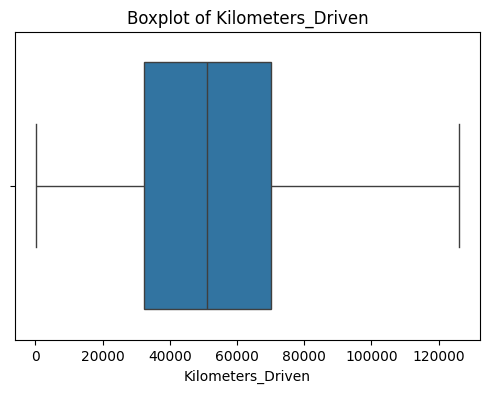

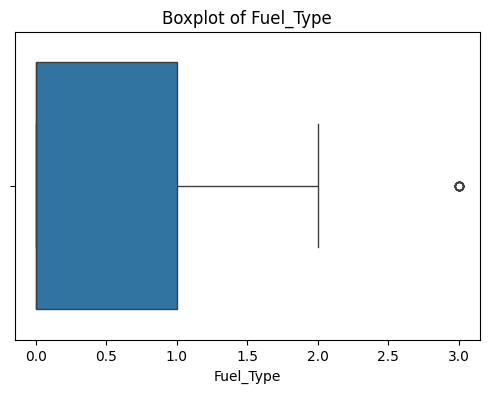

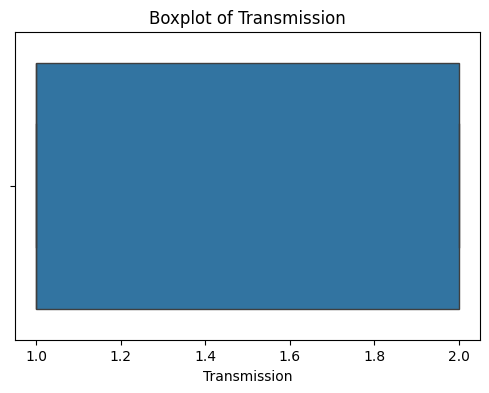

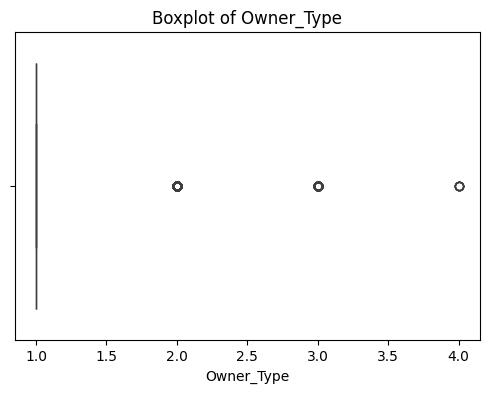

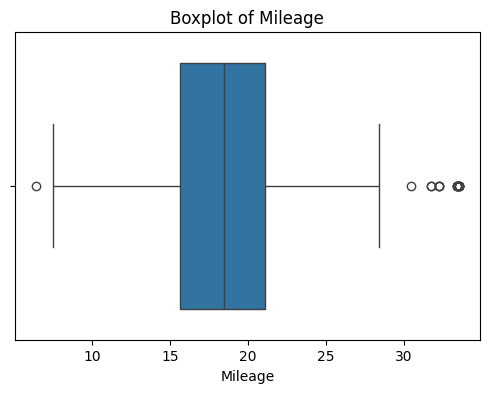

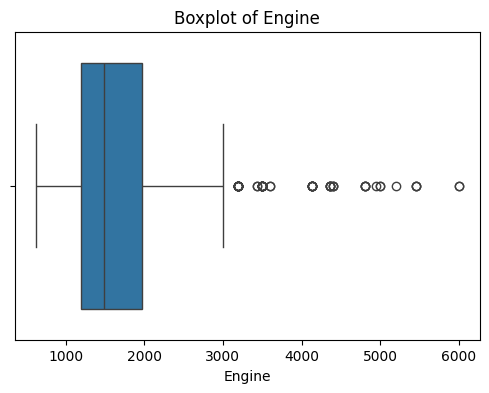

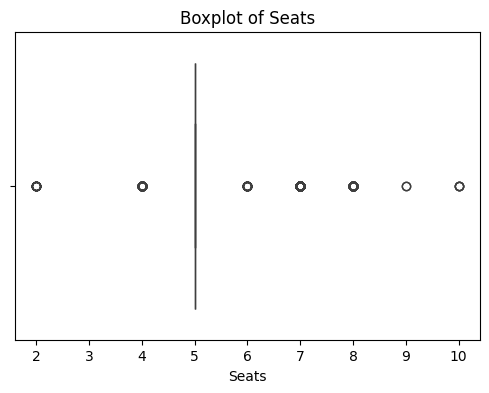

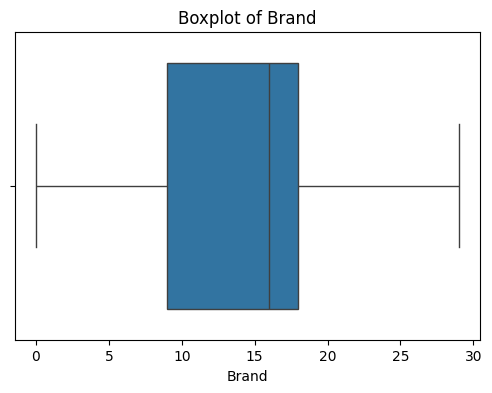

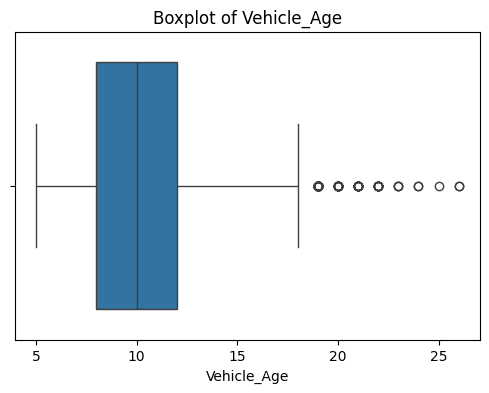

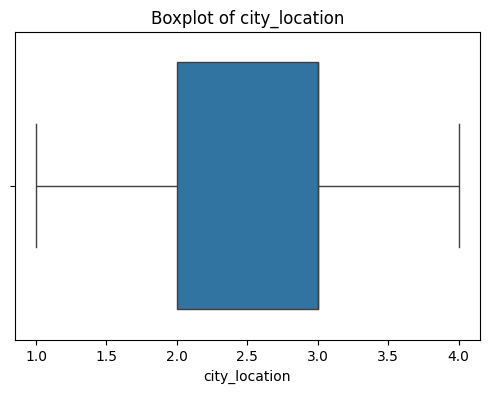

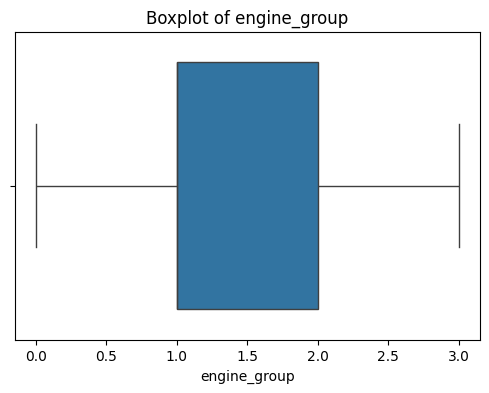

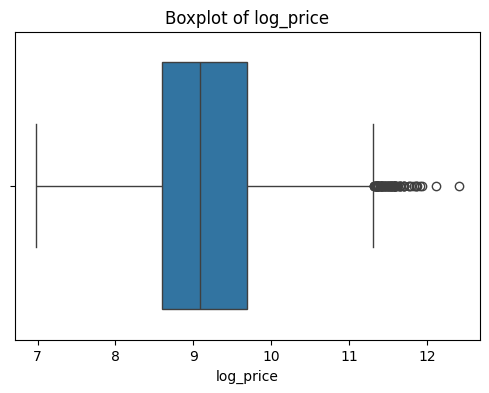

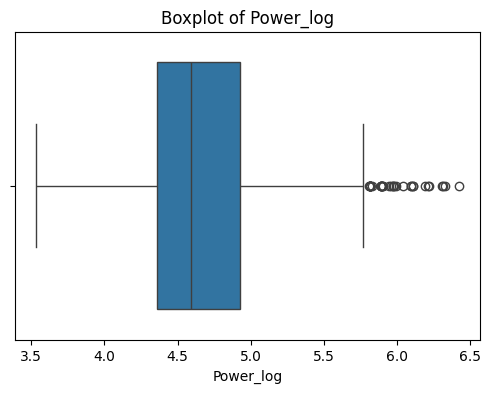

In [ ]:

numeric_cols = df_raw.select_dtypes(include=['int', 'float']).columns

# 각 숫자형 변수에 대한 Boxplot 그리기
for column in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df_raw[column])
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)
    plt.show()


seats(좌석수)가 0은 이상치로 간주  
mileage 0 은 이상치 간주  
kilometers_driven 터무니없는 높은 값은 이상치 간

In [ ]:
# df_raw[df_raw['Seats'] == 0]

In [ ]:
#Seats 이상치 1개는 삭제
# df_raw = df_raw[df_raw['Seats'] != 0] #Seats수가 0개인 차 삭제(이상치로 판별)

In [ ]:
# df_raw[df_raw['Mileage'] == 0]

,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Seats,Brand,Vehicle_Age,city_location,engine_group,log_price,Power_log


In [ ]:
#Mileage 에서 0이 아닌값들의 평균 계산
Mileage_mean = df_raw[df_raw['Mileage'] != 0]['Mileage'].mean()
#이상치(0) 평균값 대체
df_raw['Mileage'].replace(0.0, Mileage_mean, inplace=True)

In [ ]:
#kilometers_driven에서 터무니없는 큰 값이 관측됨.

Q1 = df_raw['Kilometers_Driven'].quantile(0.25)
Q3 = df_raw['Kilometers_Driven'].quantile(0.75)
IQR = Q3 - Q1

# IQR 규칙을 사용하여 이상치를 필터링
df_raw = df_raw[~((df_raw['Kilometers_Driven'] < (Q1 - 1.5 * IQR)) | (df_raw['Kilometers_Driven'] > (Q3 + 1.5 * IQR)))]

<Axes: ylabel='Kilometers_Driven'>

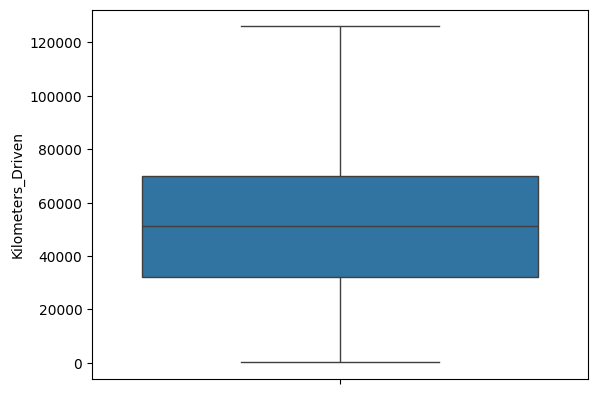

In [ ]:
sns.boxplot(df_raw['Kilometers_Driven']) #이상치 필터링 후 다시 boxplot 확인

In [ ]:
df_raw.describe() #기술통계량 재확인

,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Seats,Brand,Vehicle_Age,city_location,engine_group,log_price,Power_log
count,5934.000000,5934.000000,5934.000000,5934.000000,5934.000000,5934.000000,5934.000000,5934.000000,5934.000000,5934.000000,5934.000000,5934.000000,5934.000000
mean,52439.393495,0.490731,1.295585,1.186889,18.467277,1609.467339,5.252949,15.687732,10.404954,2.707280,1.410853,9.203072,4.641821
std,26412.438220,0.528473,0.456344,0.434432,4.136958,594.613844,0.770399,8.102957,3.144047,0.843026,0.906588,0.870786,0.413256
min,171.000000,0.000000,1.000000,1.000000,6.400000,624.000000,2.000000,0.000000,5.000000,1.000000,0.000000,6.979210,3.532226
25%,32252.500000,0.000000,1.000000,1.000000,15.630000,1197.000000,5.000000,10.000000,8.000000,2.000000,1.000000,8.602791,4.356709
50%,51081.500000,0.000000,1.000000,1.000000,18.460000,1493.000000,5.000000,17.000000,10.000000,3.000000,1.000000,9.091201,4.591071
75%,70000.000000,1.000000,2.000000,1.000000,21.120000,1968.000000,5.000000,19.000000,12.000000,3.000000,2.000000,9.686393,4.927978
max,126000.000000,3.000000,2.000000,4.000000,33.540000,5998.000000,10.000000,31.000000,26.000000,4.000000,3.000000,12.410134,6.423247


Mileage, Seats값이 0인 이상치들이 제거되었고 Kilometers_Driven	최댓값 또한 131000로 변경됨

Engine 최솟값이 72로 나와있는데, 보통 차의 engine은 1000cc 이상이라고 한다. 이상치로 간주하고 삭제!

In [ ]:
# df_raw[df_raw['Engine'] == 72.0]

In [ ]:
# df_raw = df_raw[df_raw['Engine'] != 72.0]


In [ ]:
df_raw

,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Seats,Brand,Vehicle_Age,city_location,engine_group,log_price,Power_log
0,72000,2,1,1,26.60,998.0,5.0,18,14,2,0,7.894944,4.063198
1,41000,0,1,1,19.67,1582.0,5.0,11,9,2,1,9.860737,4.837868
2,46000,1,1,1,18.20,1199.0,5.0,10,13,3,1,8.839178,4.485260
3,87000,0,1,1,20.77,1248.0,7.0,18,12,3,1,9.126824,4.485936
4,40670,0,2,2,15.20,1968.0,5.0,1,11,3,2,10.210815,4.947340
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5970,36000,1,1,1,19.83,1198.0,5.0,5,8,3,1,9.045262,4.204693
5971,41413,0,1,1,27.28,1047.0,5.0,28,8,2,1,9.289493,4.234107
5972,39015,1,1,1,17.00,1497.0,5.0,8,7,3,1,9.508645,4.798761
5973,6000,1,1,1,16.00,1368.0,5.0,14,6,2,1,10.234213,5.075174


In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5934 entries, 0 to 5974
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Kilometers_Driven  5934 non-null   int64  
 1   Fuel_Type          5934 non-null   int64  
 2   Transmission       5934 non-null   int64  
 3   Owner_Type         5934 non-null   int64  
 4   Mileage            5934 non-null   float64
 5   Engine             5934 non-null   float64
 6   Seats              5934 non-null   float64
 7   Brand              5934 non-null   int64  
 8   Vehicle_Age        5934 non-null   int64  
 9   city_location      5934 non-null   int64  
 10  engine_group       5934 non-null   int64  
 11  log_price          5934 non-null   float64
 12  Power_log          5934 non-null   float64
dtypes: float64(5), int64(8)
memory usage: 649.0 KB


In [ ]:
# df_noprice = df_raw.dropna(subset=['Price'])

In [ ]:
# #여기까지 데이터프레임 csv파일로 저장 , Price결측치 뺀 데이터프레임

# df_noprice.to_csv('noprice.csv', index=False)

### 파생변수 추가

1. Brand

In [ ]:
#자동차 모델 종류 개수 확인
# len(np.unique(list(df_raw.Name)))

In [ ]:
# df_raw['Brand'] = df_raw.Name.apply(lambda x:x.split()[0])

In [ ]:
#파생변수 생성으로 name 변수 제거
# df_raw = df_raw.drop(['Name'], axis = 1)

2. Vehicle_Age

In [ ]:
# #차량 연식 추가 (현재년도-차량모델년도)

# import datetime
# current_year = datetime.datetime.now().year
# df_raw['Vehicle_Age'] = current_year - df_raw['Year']

In [ ]:
# # Year 변수는 필요없어졌기에 제거
# df_raw = df_raw.drop(['Year'], axis = 1)

3. Brands 자동차 등급 분류

이 부분에도 전기수는 브랜드 30갠데 우리는 32개 이유는 목표변수 결측치 1000개 삭제하니 브랜드도 없어진듯 그래서 ford 추가해서

In [ ]:
brand_count = df_raw['Brand'].nunique()
print('차 브랜드 개수 : {}'.format(brand_count))

unique_brands = df_raw['Brand'].unique()
print(unique_brands)

차 브랜드 개수 : 30
[18 11 10  1 22 29 30 28 16 21 25 19  2 17  8 24  5 13 31  4 26 20  6 14
 27  0 12  7  3 15]


In [ ]:
brand_groups = { #브랜드 등급별로 분류
    'GeneralBrands': ['Maruti', 'Hyundai', 'Honda', 'Toyota', 'Nissan', 'Tata', 'Mitsubishi', 'Renault', 'Mahindra',
                       'Chevrolet', 'Skoda', 'Fiat', 'Jeep', 'Ambassador', 'ISUZU', 'Force', 'Hindustan','Ford'], #일반 브랜드
    'PremiumBrands': ['Audi', 'Volkswagen', 'Porsche', 'Mercedes-Benz', 'BMW', 'Jaguar', 'Volvo', 'Land', 'Bentley', 'Lamborghini'], #프리미엄 브랜드
    'CompactBrands': ['Datsun', 'Mini', 'Smart', 'OpelCorsa'] #소형 브랜드
}

df_raw['Brand_Group'] = df_raw['Brand'].map({brand: group for group, brands in brand_groups.items() for brand in brands})

In [ ]:
# General -> 1, Premium -> 2, Compact -> 3
df_raw['Brand_Group'] = df_raw['Brand_Group'].replace('GeneralBrands', 1)
df_raw['Brand_Group'] = df_raw['Brand_Group'].replace('PremiumBrands', 2)
df_raw['Brand_Group'] = df_raw['Brand_Group'].replace('CompactBrands', 3)

In [ ]:
from sklearn.preprocessing import LabelEncoder #Brand 데이터 값 수치형으로 변환

le = LabelEncoder()
df_raw['Brand'] = le.fit_transform(df_raw['Brand'])

brand_mapping = dict(zip(le.classes_, range(len(le.classes_))))
print(brand_mapping)

{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 10: 9, 11: 10, 12: 11, 13: 12, 14: 13, 15: 14, 16: 15, 17: 16, 18: 17, 19: 18, 20: 19, 21: 20, 22: 21, 24: 22, 25: 23, 26: 24, 27: 25, 28: 26, 29: 27, 30: 28, 31: 29}


4. location

In [ ]:
# df_raw.Location.unique()

In [ ]:
# #지역을 동서남북으로 나누어 city_location 파생변수 생성
# east = ['Kolkata']
# west = ['Mumbai', 'Pune', 'Ahmedabad']
# south = ['Chennai', 'Coimbatore', 'Kochi', 'Hyderabad', 'Bangalore']
# north = ['Jaipur', 'Delhi']

# def city2ewsn(city):
#     if city in east:
#         return 'east'
#     elif city in west:
#         return 'west'
#     elif city in south:
#         return 'south'
#     elif city in north:
#         return 'north'

# df_raw['city_location'] = df_raw.Location.apply(city2ewsn)

In [ ]:
# 동부 -> 1, 서부 -> 2, 남부 -> 3, 북부 -> 4
df_raw['city_location'] = df_raw['city_location'].replace('east', 1)
df_raw['city_location'] = df_raw['city_location'].replace('west', 2)
df_raw['city_location'] = df_raw['city_location'].replace('south', 3)
df_raw['city_location'] = df_raw['city_location'].replace('north', 4)

In [ ]:
df_raw.isnull().sum()

Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 0
Engine                  0
Seats                   0
Brand                   0
Vehicle_Age             0
city_location           0
engine_group            0
log_price               0
Power_log               0
Brand_Group          5934
dtype: int64

In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5934 entries, 0 to 5974
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Kilometers_Driven  5934 non-null   int64  
 1   Fuel_Type          5934 non-null   int64  
 2   Transmission       5934 non-null   int64  
 3   Owner_Type         5934 non-null   int64  
 4   Mileage            5934 non-null   float64
 5   Engine             5934 non-null   float64
 6   Seats              5934 non-null   float64
 7   Brand              5934 non-null   int64  
 8   Vehicle_Age        5934 non-null   int64  
 9   city_location      5934 non-null   int64  
 10  engine_group       5934 non-null   int64  
 11  log_price          5934 non-null   float64
 12  Power_log          5934 non-null   float64
 13  Brand_Group        0 non-null      object 
dtypes: float64(5), int64(8), object(1)
memory usage: 695.4+ KB


In [ ]:
df_raw

,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Seats,Brand,Vehicle_Age,city_location,engine_group,log_price,Power_log,Brand_Group
0,72000,2,1,1,26.60,998.0,5.0,17,14,2,0,7.894944,4.063198,NaN
1,41000,0,1,1,19.67,1582.0,5.0,10,9,2,1,9.860737,4.837868,NaN
2,46000,1,1,1,18.20,1199.0,5.0,9,13,3,1,8.839178,4.485260,NaN
3,87000,0,1,1,20.77,1248.0,7.0,17,12,3,1,9.126824,4.485936,NaN
4,40670,0,2,2,15.20,1968.0,5.0,1,11,3,2,10.210815,4.947340,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5970,36000,1,1,1,19.83,1198.0,5.0,5,8,3,1,9.045262,4.204693,NaN
5971,41413,0,1,1,27.28,1047.0,5.0,26,8,2,1,9.289493,4.234107,NaN
5972,39015,1,1,1,17.00,1497.0,5.0,8,7,3,1,9.508645,4.798761,NaN
5973,6000,1,1,1,16.00,1368.0,5.0,13,6,2,1,10.234213,5.075174,NaN


In [ ]:
#Price 결측치 남긴 데이터프레임 저장

df_raw.to_csv('df_car.csv', index=False)

In [ ]:
df_raw

,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Seats,Brand,Vehicle_Age,city_location,engine_group,log_price,Power_log,Brand_Group
0,72000,2,1,1,26.60,998.0,5.0,17,14,2,0,7.894944,4.063198,NaN
1,41000,0,1,1,19.67,1582.0,5.0,10,9,2,1,9.860737,4.837868,NaN
2,46000,1,1,1,18.20,1199.0,5.0,9,13,3,1,8.839178,4.485260,NaN
3,87000,0,1,1,20.77,1248.0,7.0,17,12,3,1,9.126824,4.485936,NaN
4,40670,0,2,2,15.20,1968.0,5.0,1,11,3,2,10.210815,4.947340,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5970,36000,1,1,1,19.83,1198.0,5.0,5,8,3,1,9.045262,4.204693,NaN
5971,41413,0,1,1,27.28,1047.0,5.0,26,8,2,1,9.289493,4.234107,NaN
5972,39015,1,1,1,17.00,1497.0,5.0,8,7,3,1,9.508645,4.798761,NaN
5973,6000,1,1,1,16.00,1368.0,5.0,13,6,2,1,10.234213,5.075174,NaN


In [ ]:
# df_final = df_raw.dropna(subset=['Price'])

KeyError: ['Price']

Price 결측치 삭제하고 파생변수 저장된 최종 코드 저장



#   Engine , Power_log, Seats 변수



In [ ]:
# df_raw['Power_log'] = np.log(df_raw['Power'])

In [ ]:
# # 데이터 준비
# data = df_raw['Power']  # 이 예제에서는 'Power' 열을 사용합니다.

# # 히스토그램 그리기
# plt.figure(figsize=(10, 6))  # 그래프의 크기 설정
# plt.hist(data, bins=30, alpha=0.7, color='blue', edgecolor='black', linewidth=1.2)

# # 제목과 레이블 추가
# plt.title('Power Distribution', fontsize=16)  # 제목 설정
# plt.xlabel('Power', fontsize=14)  # x축 레이블 설정
# plt.ylabel('Frequency', fontsize=14)  # y축 레이블 설정

# # 그리드 추가
# plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='grey', alpha=0.5)

# # 축 범위 조절 (옵션)
# plt.xlim([min(data)-5, max(data)+5])  # x축 범위를 데이터에 맞게 조정

# # 눈금 라벨 크기 조정
# plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)

# # 보여주기
# plt.show()

<Figure size 1000x1000 with 0 Axes>

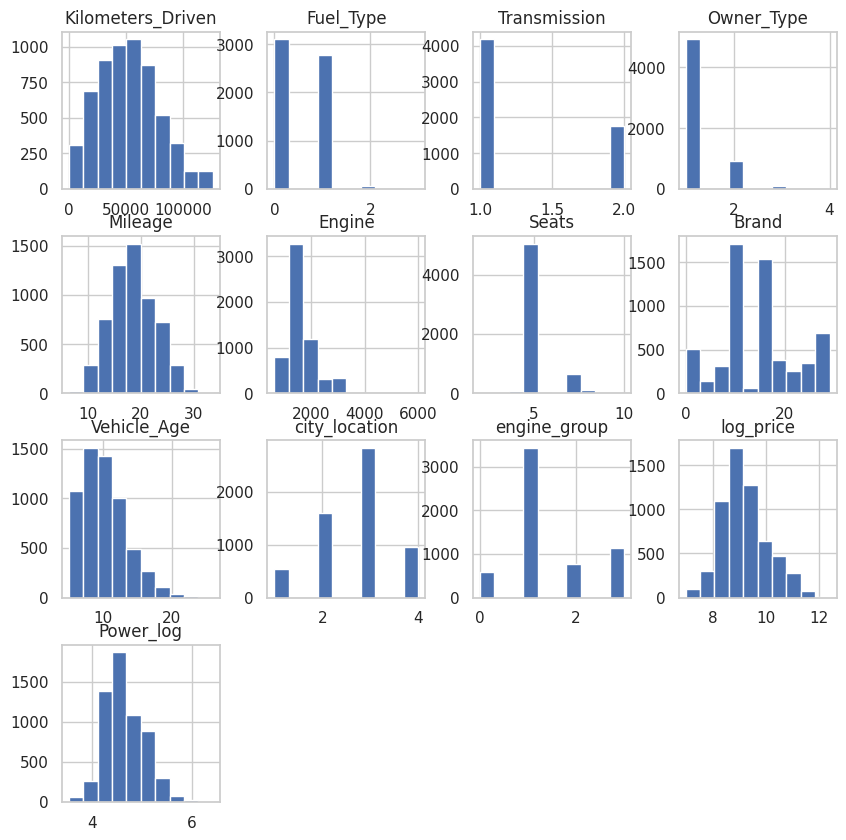

In [ ]:
fig = plt.figure(figsize=(10, 10))
df_raw.hist(figsize = (10, 10)) #히스토그램 - 데이터의 전반적인 분포를 파악
fig.subplots_adjust(wspace=0.4, hspace=0.8)

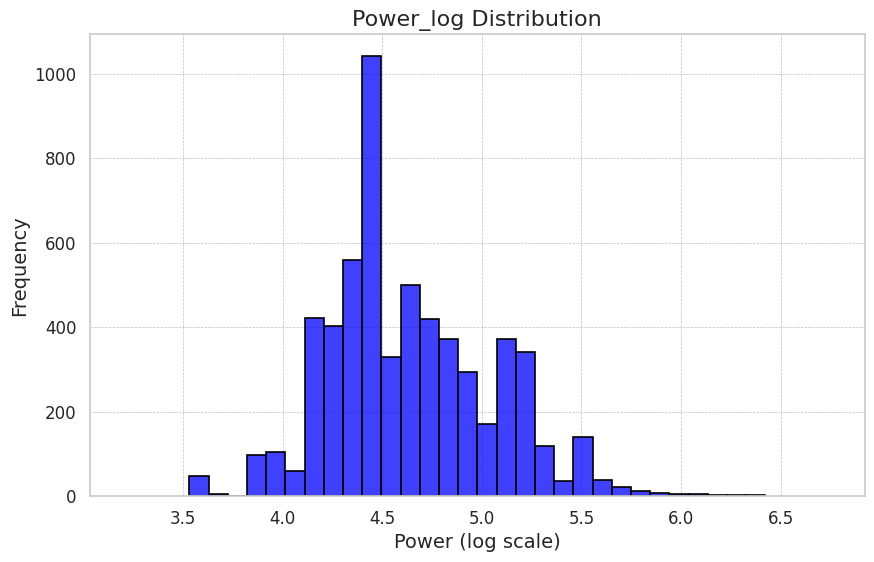

In [ ]:
# Power_log의 hist 분포 확인

# 스타일 설정
sns.set(style="whitegrid")  # seaborn 스타일 설정

# 데이터 준비
data = df_raw['Power_log']

# 그래프 그리기
plt.figure(figsize=(10, 6))
sns.histplot(data, bins=30, kde=False, color='blue', edgecolor='black', linewidth=1.2)

# 제목과 레이블 추가
plt.title('Power_log Distribution', fontsize=16)
plt.xlabel('Power (log scale)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

# 그리드 추가
plt.grid(True, linestyle='--', linewidth=0.5, color='grey', alpha=0.5)

# 눈금 라벨 크기 조정
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# 축 범위 조절 (옵션)
plt.xlim([min(data)-0.5, max(data)+0.5])

# 보여주기
plt.show()


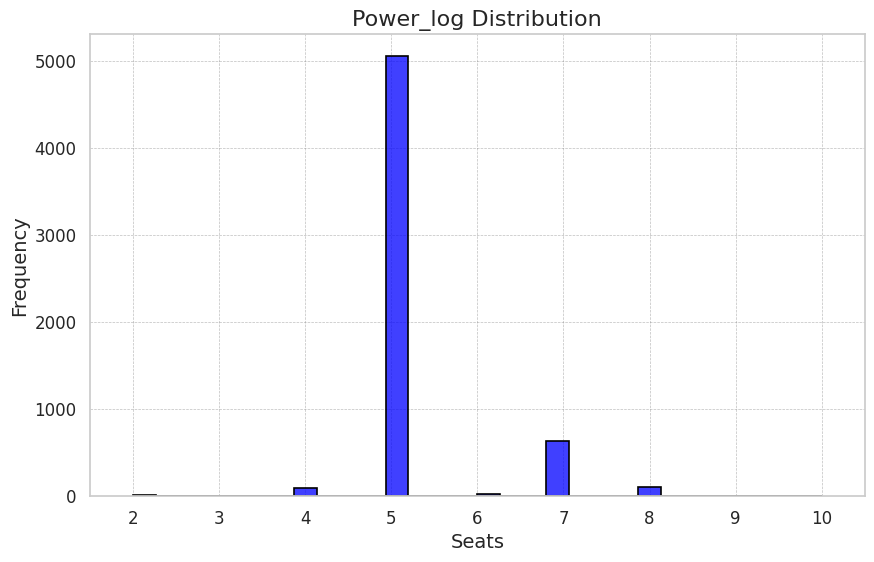

In [ ]:
# Seats의 hist 분포 확인

# 스타일 설정
sns.set(style="whitegrid")  # seaborn 스타일 설정

# 데이터 준비
data = df_raw['Seats']

# 그래프 그리기
plt.figure(figsize=(10, 6))
sns.histplot(data, bins=30, kde=False, color='blue', edgecolor='black', linewidth=1.2)

# 제목과 레이블 추가
plt.title('Power_log Distribution', fontsize=16)
plt.xlabel('Seats', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

# 그리드 추가
plt.grid(True, linestyle='--', linewidth=0.5, color='grey', alpha=0.5)

# 눈금 라벨 크기 조정
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# 축 범위 조절 (옵션)
plt.xlim([min(data)-0.5, max(data)+0.5])

# 보여주기
plt.show()


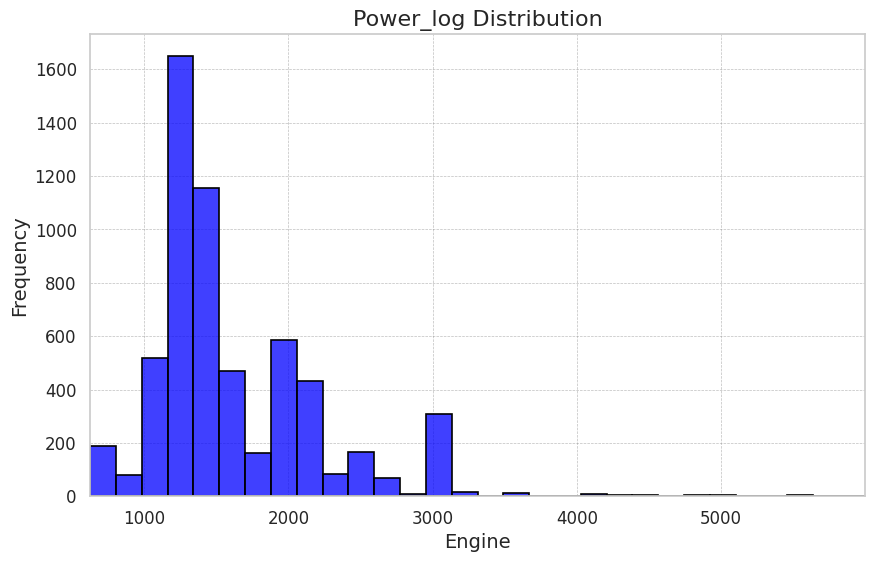

In [ ]:
# Seats의 hist 분포 확인

# 스타일 설정
sns.set(style="whitegrid")  # seaborn 스타일 설정

# 데이터 준비
data = df_raw['Engine']

# 그래프 그리기
plt.figure(figsize=(10, 6))
sns.histplot(data, bins=30, kde=False, color='blue', edgecolor='black', linewidth=1.2)

# 제목과 레이블 추가
plt.title('Power_log Distribution', fontsize=16)
plt.xlabel('Engine', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

# 그리드 추가
plt.grid(True, linestyle='--', linewidth=0.5, color='grey', alpha=0.5)

# 눈금 라벨 크기 조정
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# 축 범위 조절 (옵션)
plt.xlim([min(data)-0.5, max(data)+0.5])

# 보여주기
plt.show()


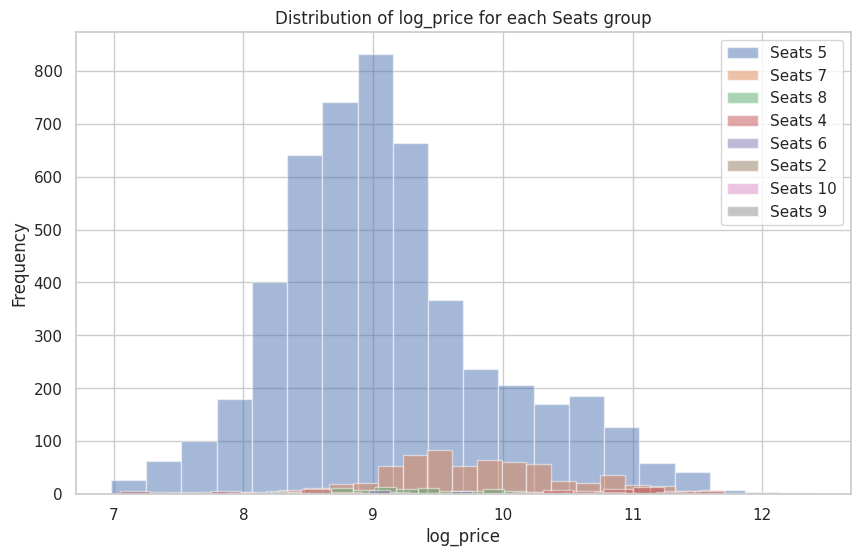

In [ ]:
import matplotlib.pyplot as plt

# 각 그룹에 대한 데이터 추출
wheel5 = df_raw[df_raw['Seats'] == 5]['log_price']
wheel7 = df_raw[df_raw['Seats'] == 7]['log_price']
wheel8 = df_raw[df_raw['Seats'] == 8]['log_price']
wheel4 = df_raw[df_raw['Seats'] == 4]['log_price']
wheel6 = df_raw[df_raw['Seats'] == 6]['log_price']
wheel2 = df_raw[df_raw['Seats'] == 2]['log_price']
wheel10 = df_raw[df_raw['Seats'] == 10]['log_price']
wheel9 = df_raw[df_raw['Seats'] == 9]['log_price']

# 각 그룹의 데이터 분포 시각화
plt.figure(figsize=(10, 6))
plt.hist(wheel5, bins=20, alpha=0.5, label='Seats 5')
plt.hist(wheel7, bins=20, alpha=0.5, label='Seats 7')
plt.hist(wheel8, bins=20, alpha=0.5, label='Seats 8')
plt.hist(wheel4, bins=20, alpha=0.5, label='Seats 4')
plt.hist(wheel6, bins=20, alpha=0.5, label='Seats 6')
plt.hist(wheel2, bins=20, alpha=0.5, label='Seats 2')
plt.hist(wheel10, bins=20, alpha=0.5, label='Seats 10')
plt.hist(wheel9, bins=20, alpha=0.5, label='Seats 9')
plt.xlabel('log_price')
plt.ylabel('Frequency')
plt.title('Distribution of log_price for each Seats group')
plt.legend()
plt.show()


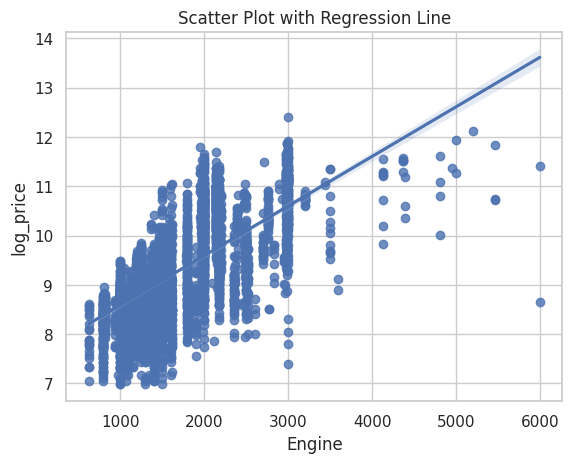

In [ ]:
# Engine과 Price_log의 산점도와 회귀선

sns.regplot(x='Engine', y='log_price', data=df_raw)
plt.title('Scatter Plot with Regression Line')
plt.xlabel('Engine')
plt.ylabel('log_price')
plt.grid(True)
plt.show()

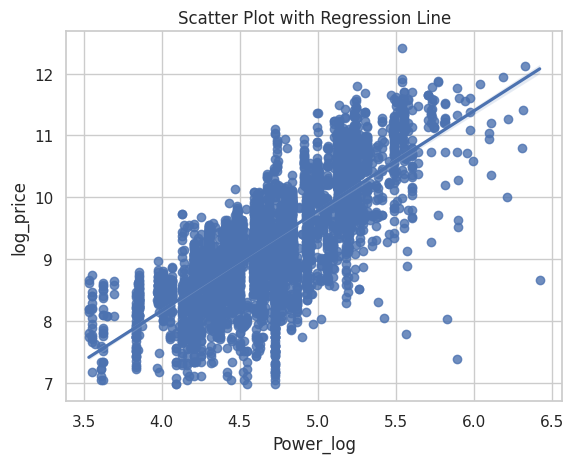

In [ ]:
# Power_log와 Price_log의 산점도와 회귀선

sns.regplot(x='Power_log', y='log_price', data=df_raw)
plt.title('Scatter Plot with Regression Line')
plt.xlabel('Power_log')
plt.ylabel('log_price')
plt.grid(True)
plt.show()

In [ ]:
# df_raw.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5934 entries, 0 to 5974
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Kilometers_Driven  5934 non-null   int64  
 1   Fuel_Type          5934 non-null   int64  
 2   Transmission       5934 non-null   int64  
 3   Owner_Type         5934 non-null   int64  
 4   Mileage            5934 non-null   float64
 5   Engine             5934 non-null   float64
 6   Seats              5934 non-null   float64
 7   Brand              5934 non-null   int64  
 8   Vehicle_Age        5934 non-null   int64  
 9   city_location      5934 non-null   int64  
 10  engine_group       5934 non-null   int64  
 11  log_price          5934 non-null   float64
 12  Power_log          5934 non-null   float64
 13  Brand_Group        0 non-null      object 
dtypes: float64(5), int64(8), object(1)
memory usage: 824.4+ KB


# 변수 검정 및 상관성 확인

In [ ]:
corr_Engine = df_raw['log_price'].corr(df_raw['Engine'])
print("상관 계수:", corr_Engine)

상관 계수: 0.6865807883536822


In [ ]:


# log_price의 유의성 검정

# 각 그룹에 대한 데이터 추출
wheel5 = df_raw[df_raw['Seats'] == 5]['log_price']
wheel7 = df_raw[df_raw['Seats'] == 7]['log_price']
wheel8 = df_raw[df_raw['Seats'] == 8]['log_price']
wheel4 = df_raw[df_raw['Seats'] == 4]['log_price']
wheel6 = df_raw[df_raw['Seats'] == 6]['log_price']
wheel2 = df_raw[df_raw['Seats'] == 2]['log_price']
wheel10 = df_raw[df_raw['Seats'] == 10]['log_price']
wheel9 = df_raw[df_raw['Seats'] == 9]['log_price']

# 일원배치 분산분석 실시
f_statistic, p_value = f_oneway(wheel5, wheel7, wheel8, wheel4, wheel6, wheel2, wheel10, wheel9)

# 결과 출력
print("F-통계량 (F-statistic):", f_statistic)
print("p-value:", p_value)

# p-value를 기준으로 가설 검정
alpha = 0.05
if p_value < alpha:
    print("p-value가 유의수준 0.05보다 작으므로 귀무가설을 기각합니다. 그룹 간의 평균 차이가 존재합니다.")
else:
    print("p-value가 유의수준 0.05보다 크거나 같으므로 귀무가설을 기각하지 못합니다. 그룹 간의 평균 차이가 존재하지 않습니다.")


F-통계량 (F-statistic): 74.23554863786933
p-value: 1.8381692726696005e-103
p-value가 유의수준 0.05보다 작으므로 귀무가설을 기각합니다. 그룹 간의 평균 차이가 존재합니다.


In [ ]:
# Engine Group과 log_price의 정규성 검정

# 데이터 설정
X = df_raw[['engine_group']]  # 독립 변수
y = df_raw['log_price']  # 종속 변수

# 회귀 모델 적합
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

# 잔차 계산
residuals = model.resid

# Shapiro-Wilk 테스트를 사용하여 잔차의 정규성 검정
statistic, p_value = shapiro(residuals)
print("Shapiro-Wilk 검정 통계량:", statistic)
print("p-value:", p_value)

# p-value를 기준으로 유의수준에 따라 정규성 판단
alpha = 0.05
if p_value < alpha:
    print("p-value가 유의수준 0.05보다 작으므로 잔차는 정규분포를 따르지 않습니다.")
else:
    print("p-value가 유의수준 0.05보다 크거나 같으므로 잔차는 정규분포를 따릅니다.")


Shapiro-Wilk 검정 통계량: 0.9939925670623779
p-value: 4.266593470262899e-15
p-value가 유의수준 0.05보다 작으므로 잔차는 정규분포를 따르지 않습니다.


In [ ]:
from scipy.stats import chi2_contingency

# 카테고리화된 Seats 변수 생성
df_raw['Seats_category'] = pd.cut(df_raw['Seats'], bins=[0, 5, 7, 10], labels=['5', '7', '10+'])

# 교차 테이블 생성
cross_table = pd.crosstab(df_raw['Seats_category'], pd.qcut(df_raw['log_price'], 3), margins=True)

# 카이제곱 동질성 검정 수행
chi2_statistic, p_value, dof, expected = chi2_contingency(cross_table)

# 결과 출력
print("Chi-square statistic:", chi2_statistic)
print("p-value:", p_value)

# p-value를 기준으로 유의수준에 따라 동질성 판단
alpha = 0.05
if p_value < alpha:
    print("p-value가 유의수준 0.05보다 작으므로 귀무가설을 기각합니다. 즉, 변수들 간에는 동질성이 없습니다.")
else:
    print("p-value가 유의수준 0.05보다 크거나 같으므로 귀무가설을 기각하지 않습니다. 즉, 변수들 간에는 동질성이 있습니다.")


Chi-square statistic: 484.29616939434356
p-value: 1.3223883499337135e-98
p-value가 유의수준 0.05보다 작으므로 귀무가설을 기각합니다. 즉, 변수들 간에는 동질성이 없습니다.


In [ ]:
from scipy.stats import f_oneway

# 각 그룹에 대한 데이터 추출
seats1 = df_raw[df_raw['Seats'] == 1]['log_price']
seats2 = df_raw[df_raw['Seats'] == 2]['log_price']
seats3 = df_raw[df_raw['Seats'] == 3]['log_price']
seats4 = df_raw[df_raw['Seats'] == 4]['log_price']

# 일원배치 분산분석 실시
f_statistic, p_value = f_oneway(seats1, seats2, seats3, seats4)

# 결과 출력
print("F-통계량 (F-statistic):", f_statistic)
print("p-value:", p_value)

# p-value를 기준으로 가설 검정
alpha = 0.05
if p_value < alpha:
    print("p-value가 유의수준 0.05보다 작으므로 귀무가설을 기각합니다. 그룹 간의 평균 차이가 존재합니다.")
else:
    print("p-value가 유의수준 0.05보다 크거나 같으므로 귀무가설을 기각하지 못합니다. 그룹 간의 평균 차이가 존재하지 않습니다.")


F-통계량 (F-statistic): nan
p-value: nan
p-value가 유의수준 0.05보다 크거나 같으므로 귀무가설을 기각하지 못합니다. 그룹 간의 평균 차이가 존재하지 않습니다.
